# Regularized Logistic Regression for Diabetes Classification

## Objective

The objective of this project is to classify diabetes using the Pima Indians Diabetes dataset and explore the effect of regularization on logistic regression. Ordinary logistic regression is compared with **Ridge (L2)** and **Lasso (L1)** regularized logistic regression, with model performance evaluated using **Leave-One-Out Cross-Validation (LOOCV)**.

The project also explores how Ridge and Lasso affect model coefficients and how regularization can help control model complexity.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the Pima Indians Diabetes dataset

df = pd.read_csv("diabetes.csv")

In [3]:
# Display the first five rows of the dataset

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,1,89,66,23,94,28.1,0.167,21,0
3,0,137,40,35,168,43.1,2.288,33,1
4,5,116,74,0,0,25.6,0.201,30,0


## Exploratory Data Analysis (EDA)

In [4]:
# Check the dimensions of the dataset

df.shape

(768, 9)

In [5]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
# Check for missing values

df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [7]:
# Count zero values in each column

(df == 0).sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

### Data Quality Check

Although the dataset contains no `NaN` values, several clinical variables contain zero values that may represent missing or unavailable measurements. Zero is valid for **Pregnancies** and **Outcome**, but values of zero for **Glucose, BloodPressure, SkinThickness, Insulin, and BMI** may not represent meaningful physiological measurements.

For this analysis, these zero values are retained to maintain consistency with the original dataset and to keep the focus on comparing Logistic Regression, Ridge, and Lasso regularization. Their potential impact should be considered when interpreting the results.

In [8]:
# Generate summary statistics for the numerical variables

df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [9]:
# Count the number of observations in each outcome class

df['Outcome'].value_counts()

0    500
1    268
Name: Outcome, dtype: int64

### Target Variable Distribution

The dataset contains **500 observations without diabetes (Outcome = 0)** and **268 observations with diabetes (Outcome = 1)**. The target variable is moderately imbalanced, with more observations belonging to the non-diabetic class.

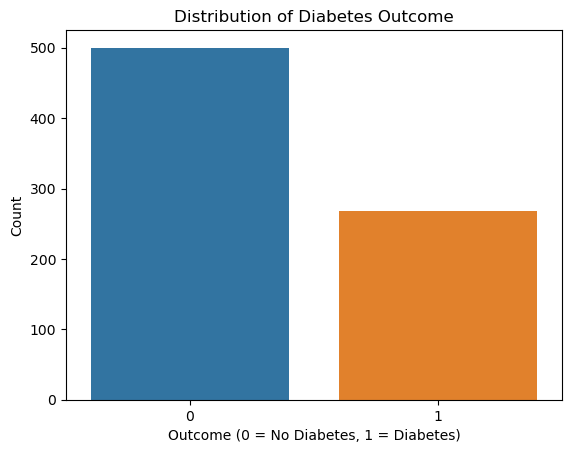

In [10]:
# Visualize the distribution of the outcome classes

sns.countplot(data=df, x='Outcome')

plt.title('Distribution of Diabetes Outcome')
plt.xlabel('Outcome (0 = No Diabetes, 1 = Diabetes)')
plt.ylabel('Count')

plt.savefig('Figures/outcome_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## Predictor Distributions

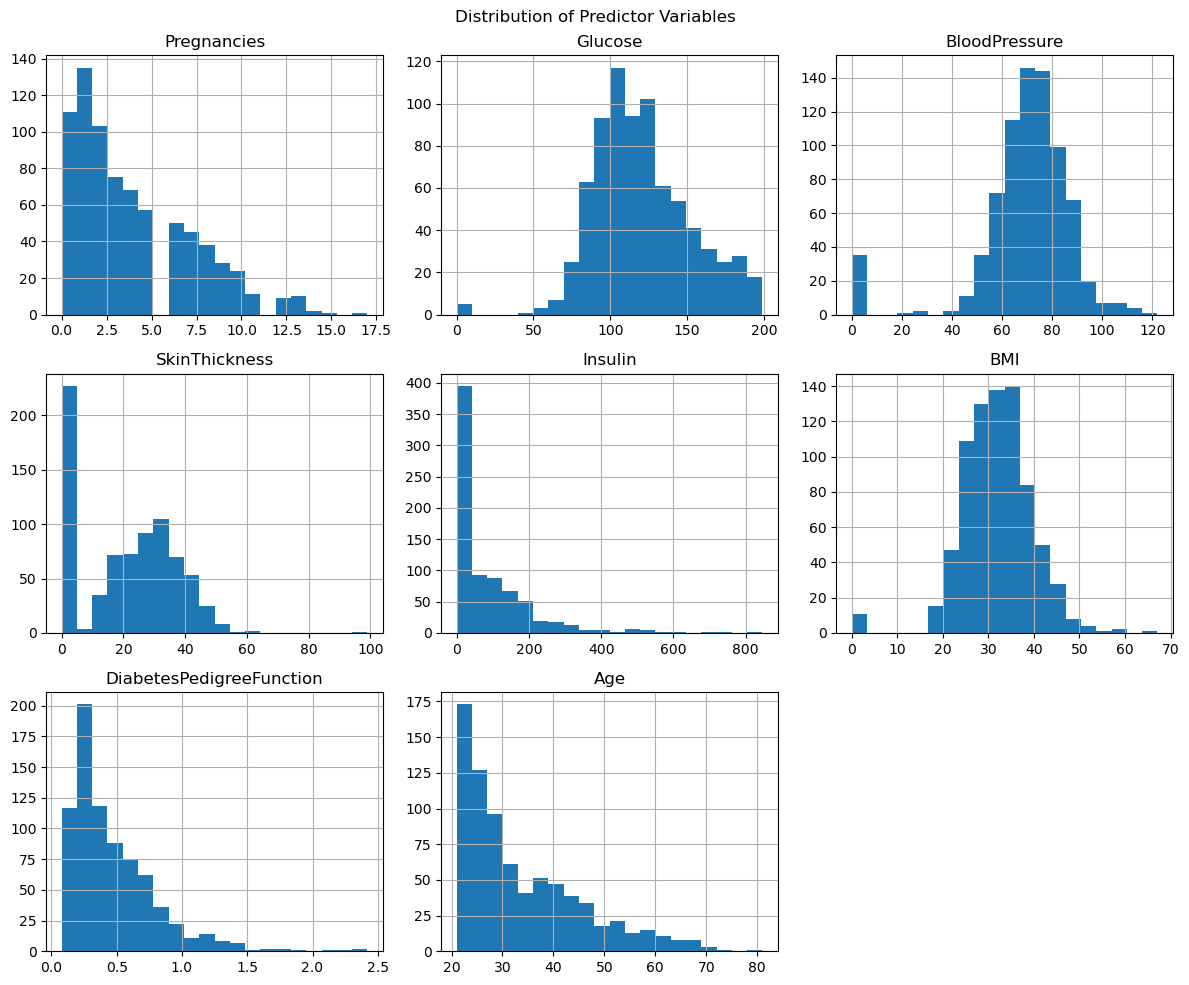

In [11]:
# Visualize the distributions of the predictor variables

df.drop(columns='Outcome').hist(figsize=(12,10), bins=20)

plt.suptitle('Distribution of Predictor Variables')
plt.tight_layout()
plt.savefig('Figures/predictor_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

### Interpretation

The predictor variables have different distributions and measurement scales. **Insulin, DiabetesPedigreeFunction, Age, and Pregnancies** show noticeable right-skewness. Several clinical variables also contain zero values, particularly **Insulin** and **SkinThickness**. These differences in scale are important because Ridge and Lasso regularization penalize model coefficients, making **feature standardization an important preprocessing step** before fitting the regularized models.

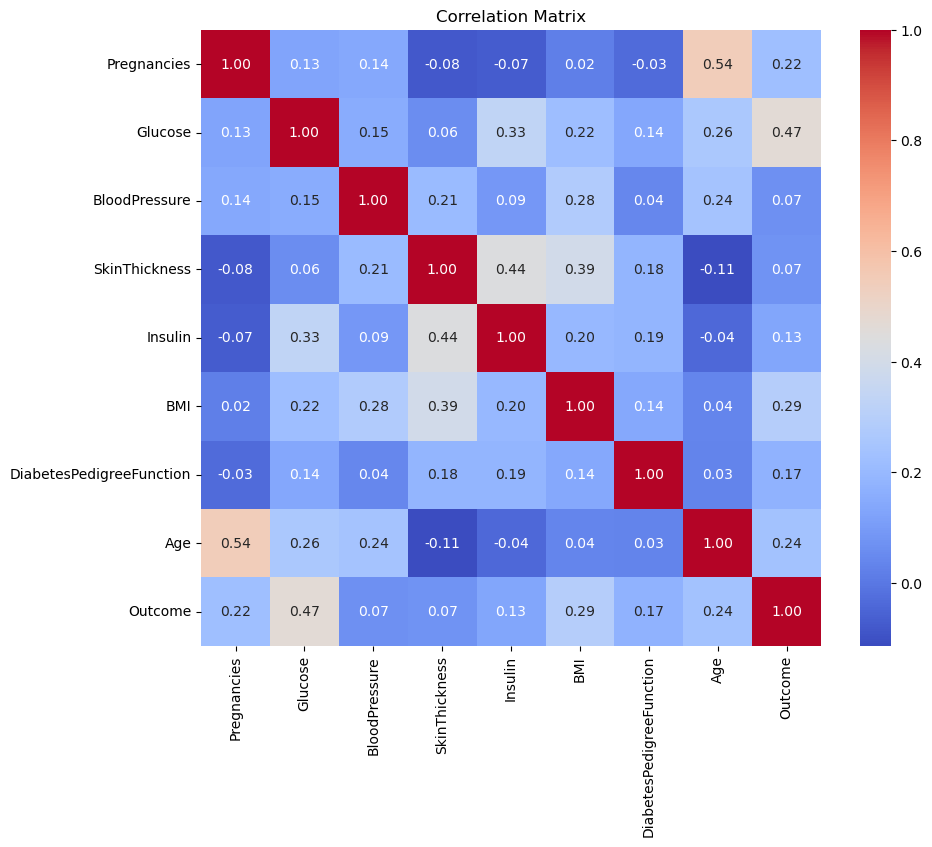

In [12]:
# Visualize correlations between variables

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')

plt.title('Correlation Matrix')
plt.savefig('Figures/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

### Interpretation

**Glucose** shows the strongest positive correlation with diabetes outcome (**r = 0.47**), followed by **BMI (r = 0.29)**, **Age (r = 0.24)**, and **Pregnancies (r = 0.22)**. Some predictors are also moderately correlated with each other, such as **Pregnancies and Age (r = 0.54)**. These relationships provide useful context for comparing ordinary, Ridge, and Lasso logistic regression.

## Data Preprocessing

In [13]:
# Separate predictors and target variable
X= df.drop(columns= "Outcome")
y= df["Outcome"]

In [14]:
# Check the dimensions of predictors and target

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (768, 8)
y shape: (768,)


In [15]:
# Import StandardScaler

from sklearn.preprocessing import StandardScaler

## Logistic Regression with Leave-One-Out Cross-Validation (LOOCV)

Ordinary logistic regression is first used as a baseline model. Leave-One-Out Cross-Validation (LOOCV) is used to estimate the test error rate.

In [16]:
# Import libraries for Logistic Regression and LOOCV

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.pipeline import make_pipeline

In [17]:
# Create Leave-One-Out Cross-Validation

loocv = LeaveOneOut()

In [18]:
# Create a pipeline with standardization and unpenalized logistic regression

logistic_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(penalty='none', max_iter=1000)
)

In [19]:
# Compute LOOCV accuracy for logistic regression

logistic_accuracy_scores = cross_val_score(
    logistic_model,
    X,
    y,
    cv=loocv,
    scoring='accuracy'
)

logistic_accuracy = logistic_accuracy_scores.mean()
logistic_accuracy

0.77734375

In [20]:
# Calculate the LOOCV test error rate

logistic_test_error = 1 - logistic_accuracy
logistic_test_error

0.22265625

### Interpretation

The ordinary logistic regression model achieved a **LOOCV accuracy of 77.73%** and an estimated **test error rate of 22.27%**. This model serves as the baseline for comparison with Ridge and Lasso regularized logistic regression..

## Ridge Logistic Regression (L2 Regularization)

Ridge logistic regression applies an **L2 penalty** that shrinks model coefficients toward zero. The regularization strength is selected using Leave-One-Out Cross-Validation (LOOCV).

In [21]:
# Define candidate values for the Ridge regularization parameter C

C_values = [0.01, 0.1, 1, 10, 100]

In [22]:
# Evaluate Ridge logistic regression for different C values using LOOCV

ridge_errors = []

for C in C_values:
    ridge_model = make_pipeline(
        StandardScaler(),
        LogisticRegression(penalty='l2', C=C, max_iter=1000)
    )
    
    scores = cross_val_score(
        ridge_model,
        X,
        y,
        cv=loocv,
        scoring='accuracy'
    )
    
    test_error = 1 - scores.mean()
    ridge_errors.append(test_error)

ridge_errors

[0.23046875, 0.2265625, 0.22395833333333337, 0.22265625, 0.22265625]

In [23]:
# Find the C value with the lowest LOOCV test error

best_index = np.argmin(ridge_errors)
best_C_ridge = C_values[best_index]
best_ridge_error = ridge_errors[best_index]

print("Best C:", best_C_ridge)
print("Best Ridge LOOCV Test Error:", best_ridge_error)

Best C: 10
Best Ridge LOOCV Test Error: 0.22265625


In [24]:
# Fit the final Ridge logistic regression model using the best C

ridge_final = make_pipeline(
    StandardScaler(),
    LogisticRegression(penalty='l2', C=best_C_ridge, max_iter=1000)
)

ridge_final.fit(X, y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression',
                 LogisticRegression(C=10, max_iter=1000))])

In [25]:
# Display the Ridge logistic regression coefficients

ridge_coefficients = ridge_final.named_steps['logisticregression'].coef_[0]

ridge_coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Ridge Coefficient': ridge_coefficients
})

ridge_coef_df

,Feature,Ridge Coefficient
0,Pregnancies,0.414178
1,Glucose,1.121861
2,BloodPressure,-0.256513
3,SkinThickness,0.009767
4,Insulin,-0.136586
5,BMI,0.705684
6,DiabetesPedigreeFunction,0.312546
7,Age,0.174919


### Ridge Coefficient Interpretation

The Ridge model retains all predictors while shrinking their coefficients toward zero. **Glucose** has the largest positive coefficient (**1.122**), followed by **BMI (0.706)** and **Pregnancies (0.414)**. **SkinThickness** has a coefficient close to zero but is still retained in the model, illustrating that Ridge typically shrinks coefficients rather than eliminating predictors.

## Lasso Logistic Regression (L1 Regularization)

Lasso logistic regression applies an **L1 penalty**, which shrinks model coefficients and can reduce some coefficients exactly to zero. Therefore, Lasso can also perform automatic feature selection. The regularization strength is selected using LOOCV.

In [26]:
# Define candidate values for the Lasso regularization parameter C

C_values = [0.01, 0.1, 1, 10, 100]

In [27]:
# Evaluate Lasso logistic regression for different C values using LOOCV

lasso_errors = []

for C in C_values:
    lasso_model = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            penalty='l1',
            C=C,
            solver='liblinear',
            max_iter=1000) )
    
    scores = cross_val_score(
        lasso_model,
        X,
        y,
        cv=loocv,
        scoring='accuracy' )
    
    test_error = 1 - scores.mean()
    lasso_errors.append(test_error)

lasso_errors

[0.27213541666666663,
 0.22786458333333337,
 0.22265625,
 0.22395833333333337,
 0.22265625]

In [28]:
# Find the C value with the lowest Lasso LOOCV test error

best_index = np.argmin(lasso_errors)
best_C_lasso = C_values[best_index]
best_lasso_error = lasso_errors[best_index]
print("Best C:", best_C_lasso)
print("Best Lasso LOOCV Test Error:", best_lasso_error)

Best C: 1
Best Lasso LOOCV Test Error: 0.22265625


In [29]:

# Fit the final Lasso logistic regression model using the best C

lasso_final = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        penalty='l1',
        C=best_C_lasso,
        solver='liblinear',
        max_iter=1000
    )
)

lasso_final.fit(X, y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression',
                 LogisticRegression(C=1, max_iter=1000, penalty='l1',
                                    solver='liblinear'))])

In [30]:
# Display the Lasso logistic regression coefficients

lasso_coefficients = lasso_final.named_steps['logisticregression'].coef_[0]

lasso_coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Lasso Coefficient': lasso_coefficients
})

lasso_coef_df

,Feature,Lasso Coefficient
0,Pregnancies,0.404858
1,Glucose,1.102133
2,BloodPressure,-0.239066
3,SkinThickness,0.000000
4,Insulin,-0.120164
5,BMI,0.688344
6,DiabetesPedigreeFunction,0.301585
7,Age,0.167515


### Lasso Coefficient Interpretation

The Lasso model shrinks the coefficients toward zero and sets the coefficient for **SkinThickness exactly to zero**, effectively removing this predictor from the model. **Glucose** has the largest positive coefficient, followed by **BMI** and **Pregnancies**. This demonstrates the feature-selection property of Lasso regularization.

## Model Comparison

The coefficients and LOOCV test error rates of ordinary Logistic Regression, Ridge, and Lasso are compared to evaluate the effect of regularization.

In [31]:
# Fit ordinary logistic regression to obtain coefficients

logistic_final = make_pipeline(
    StandardScaler(),
    LogisticRegression(penalty='none', max_iter=1000)
)

logistic_final.fit(X, y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression',
                 LogisticRegression(max_iter=1000, penalty='none'))])

In [32]:
# Extract the ordinary logistic regression coefficients

logistic_coefficients = logistic_final.named_steps['logisticregression'].coef_[0]

In [33]:
# Compare coefficients from Logistic, Ridge, and Lasso models

coefficient_comparison = pd.DataFrame({
    'Feature': X.columns,
    'Logistic': logistic_coefficients,
    'Ridge': ridge_coefficients,
    'Lasso': lasso_coefficients
})

coefficient_comparison.round(4)

,Feature,Logistic,Ridge,Lasso
0,Pregnancies,0.4148,0.4142,0.4049
1,Glucose,1.1235,1.1219,1.1021
2,BloodPressure,-0.2572,-0.2565,-0.2391
3,SkinThickness,0.0099,0.0098,0.0000
4,Insulin,-0.1372,-0.1366,-0.1202
5,BMI,0.7068,0.7057,0.6883
6,DiabetesPedigreeFunction,0.3130,0.3125,0.3016
7,Age,0.1747,0.1749,0.1675


### Coefficient Comparison

The three models produce similar coefficient estimates, but regularization shrinks the coefficients toward zero. Ridge retains all predictors with slightly smaller coefficients, while Lasso shrinks **SkinThickness** exactly to zero, effectively removing it from the model. **Glucose** has the largest positive coefficient across all three models, followed by **BMI**.

In [34]:
# Compare LOOCV test error rates

model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Ridge', 'Lasso'],
    'Best C': ['None', best_C_ridge, best_C_lasso],
    'LOOCV Test Error': [
        logistic_test_error,
        best_ridge_error,
        best_lasso_error
    ]
})

model_comparison

,Model,Best C,LOOCV Test Error
0,Logistic Regression,None,0.222656
1,Ridge,10,0.222656
2,Lasso,1,0.222656


### Model Comparison Interpretation

All three models achieved the same **LOOCV test error rate of 22.27%**, indicating that Ridge and Lasso regularization did not improve classification error compared with ordinary logistic regression.

However, Lasso produced a simpler model by shrinking the coefficient of **SkinThickness to zero**, while maintaining the same predictive performance. Ridge retained all predictors.

Based on these results, **Lasso may be preferred when model simplicity and feature selection are desired**, while ordinary logistic regression provides comparable predictive performance without regularization.

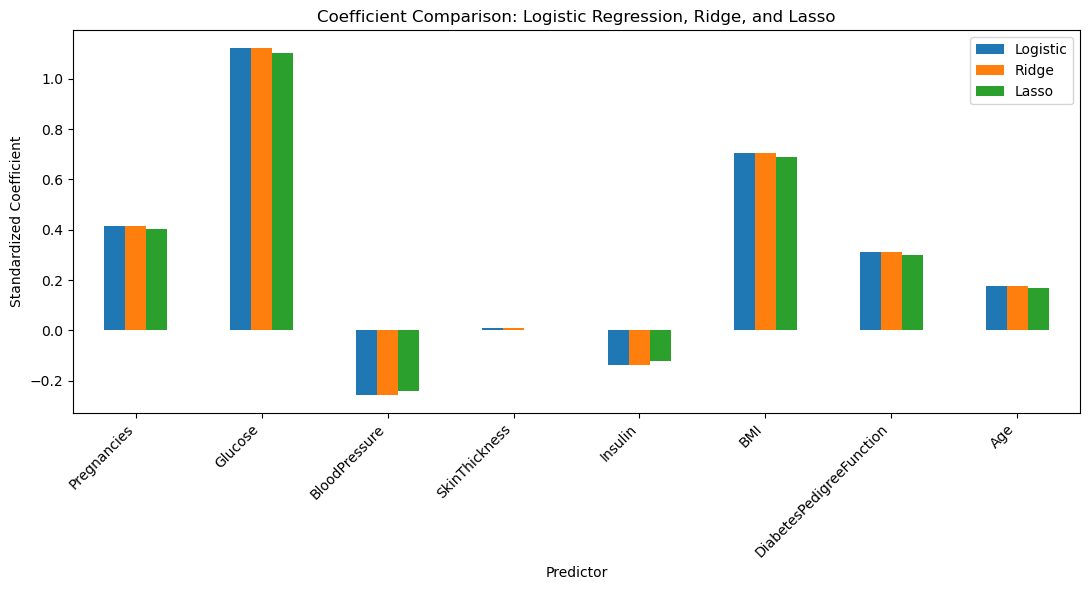

In [35]:
# Visualize coefficient estimates across the three models

coefficient_plot = coefficient_comparison.set_index('Feature')

coefficient_plot.plot(kind='bar', figsize=(11,6))

plt.title('Coefficient Comparison: Logistic Regression, Ridge, and Lasso')
plt.xlabel('Predictor')
plt.ylabel('Standardized Coefficient')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig('Figures/coefficient_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

### Interpretation

The coefficient patterns are similar across all three models. Ridge slightly shrinks the coefficients toward zero, while Lasso applies stronger shrinkage and reduces **SkinThickness** to zero. **Glucose** has the largest positive coefficient across all three models, followed by **BMI**.

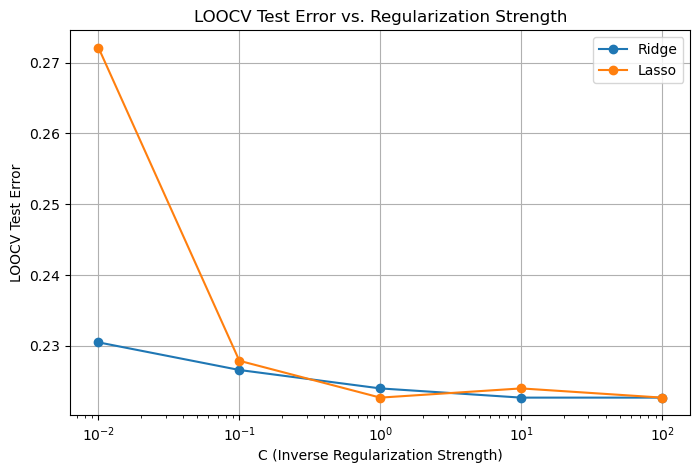

In [36]:
# Visualize LOOCV test error for different regularization strengths

plt.figure(figsize=(8,5))

plt.plot(C_values, ridge_errors, marker='o', label='Ridge')
plt.plot(C_values, lasso_errors, marker='o', label='Lasso')

plt.xscale('log')
plt.xlabel('C (Inverse Regularization Strength)')
plt.ylabel('LOOCV Test Error')
plt.title('LOOCV Test Error vs. Regularization Strength')
plt.legend()
plt.grid(True)

plt.savefig('Figures/loocv_regularization.png', dpi=300, bbox_inches='tight')
plt.show()

### Interpretation

The LOOCV test error changes with the regularization strength. Ridge achieved its minimum test error at **C = 10**, while Lasso achieved its first minimum at **C = 1**. Very strong regularization, particularly for Lasso at small C values, increased the test error. This demonstrates how cross-validation can be used to select an appropriate regularization strength.

## Conclusion

This project compared ordinary logistic regression with Ridge (L2) and Lasso (L1) regularized logistic regression for diabetes classification using Leave-One-Out Cross-Validation (LOOCV).

All three models achieved the same estimated **LOOCV test error of 22.27%**, indicating that regularization did not improve classification error for this dataset.

Ridge achieved its minimum test error at **C = 10** and retained all predictors while shrinking their coefficients toward zero. Lasso achieved its minimum test error at **C = 1** and reduced the coefficient of **SkinThickness to zero**, demonstrating its ability to perform feature selection.

Overall, the three models provided similar predictive performance. However, Lasso produced a slightly simpler model while maintaining the same LOOCV test error.